#  **FIFA World Cup 2022 Performance Analysis**

This project analyzes team performance in the FIFA World Cup 2022 using Python and statistical techniques. The objective is to identify overperforming and underperforming teams based on FIFA rankings and historical performance.

##  **Objectives**

- Analyze host country performance over time
- Compare Qatar’s performance with historical hosts
- Identify overperforming and underperforming teams
- Analyze Argentina’s path to victory
- Study relationship between FIFA ranking and performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Loading**

In [2]:
world_cup_groups_2022 = pd.read_csv("/content/2022_world_cup_groups.csv")
world_cup_groups_2022.head()
world_cup_groups_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Group         32 non-null     object
 1   Team          32 non-null     object
 2   FIFA Ranking  32 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 900.0+ bytes


In [3]:
world_cup_matches_2022 = pd.read_csv("/content/2022_world_cup_matches.csv")
world_cup_matches_2022.head()
world_cup_matches_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         64 non-null     int64 
 1   Year       64 non-null     int64 
 2   Date       64 non-null     object
 3   Stage      64 non-null     object
 4   Home Team  64 non-null     object
 5   Away Team  64 non-null     object
 6   Host Team  48 non-null     object
dtypes: int64(2), object(5)
memory usage: 3.6+ KB


In [4]:
international_matches = pd.read_csv("/content/international_matches.csv")
international_matches.head()
international_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17769 entries, 0 to 17768
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              17769 non-null  int64 
 1   Tournament      17769 non-null  object
 2   Date            17769 non-null  object
 3   Home Team       17769 non-null  object
 4   Home Goals      17769 non-null  int64 
 5   Away Goals      17769 non-null  int64 
 6   Away Team       17769 non-null  object
 7   Win Conditions  201 non-null    object
 8   Home Stadium    17769 non-null  bool  
dtypes: bool(1), int64(3), object(5)
memory usage: 1.1+ MB


In [5]:
world_cups = pd.read_csv("/content/world_cups.csv")
world_cups.head()
world_cups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             22 non-null     int64  
 1   Host Country     22 non-null     object 
 2   Winner           21 non-null     object 
 3   Runners-Up       21 non-null     object 
 4   Third            21 non-null     object 
 5   Fourth           21 non-null     object 
 6   Goals Scored     21 non-null     float64
 7   Qualified Teams  22 non-null     int64  
 8   Matches Played   22 non-null     int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 1.7+ KB


In [6]:
host_performance = world_cups[['Year','Host Country','Winner','Runners-Up','Third','Fourth']]
host_performance.head()

,Year,Host Country,Winner,Runners-Up,Third,Fourth
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria
2,1938,France,Italy,Hungary,Brazil,Sweden
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay


In [7]:
import pandas as pd
world_cup_groups_2022 = pd.read_csv("/content/2022_world_cup_groups.csv")
teams_2022 = world_cup_groups_2022
teams_2022.head()

,Group,Team,FIFA Ranking
0,A,Qatar,50
1,A,Ecuador,44
2,A,Senegal,18
3,A,Netherlands,8
4,B,England,5


# **Feature Engineering**

In [8]:
def host_stage(row):
    if row['Host Country'] == row['Winner']:
        return "Winner"
    elif row['Host Country'] == row['Runners-Up']:
        return "Final"
    elif row['Host Country'] == row['Third']:
        return "Third"
    elif row['Host Country'] == row['Fourth']:
        return "Fourth"
    else:
        return "Below Top 4"

host_performance['Host_Result'] = host_performance.apply(host_stage, axis=1)

/tmp/ipykernel_25063/389220236.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  host_performance['Host_Result'] = host_performance.apply(host_stage, axis=1)


In [ ]:
stage_score = {
    "Winner":7,
    "Final":6,
    "Third":5,
    "Fourth":4,
    "Below Top 4":1
}

host_performance['Score'] = host_performance['Host_Result'].map(stage_score)

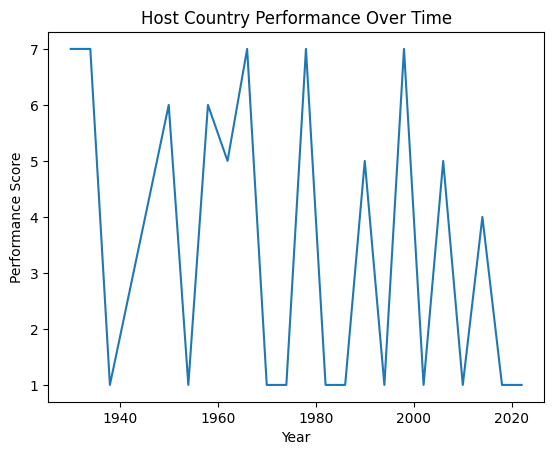

In [10]:
plt.figure()
plt.plot(host_performance['Year'], host_performance['Score'])
plt.title("Host Country Performance Over Time")
plt.xlabel("Year")
plt.ylabel("Performance Score")
plt.show()



##  **Interpretation**

The chart shows that host countries generally perform well over time, indicating a home advantage. However, performance varies across tournaments. Qatar (2022) performed below the historical trend, suggesting weaker host advantage in this case.

In [11]:
host_performance[host_performance['Year'] == 2022]

,Year,Host Country,Winner,Runners-Up,Third,Fourth,Host_Result,Score
21,2022,Qatar,NaN,NaN,NaN,NaN,Below Top 4,1


In [12]:
host_performance['Score'].mean()

np.float64(3.5)

In [13]:

home_team_wins = international_matches[international_matches['Home Goals'] > international_matches['Away Goals']][['Home Team']].copy()
home_team_wins.rename(columns={'Home Team': 'Team'}, inplace=True)
home_team_wins['Wins'] = 1
away_team_wins = international_matches[international_matches['Away Goals'] > international_matches['Home Goals']][['Away Team']].copy()
away_team_wins.rename(columns={'Away Team': 'Team'}, inplace=True)
away_team_wins['Wins'] = 1
home_team_non_wins = international_matches[international_matches['Home Goals'] <= international_matches['Away Goals']][['Home Team']].copy()
home_team_non_wins.rename(columns={'Home Team': 'Team'}, inplace=True)
home_team_non_wins['Wins'] = 0
away_team_non_wins = international_matches[international_matches['Away Goals'] <= international_matches['Home Goals']][['Away Team']].copy()
away_team_non_wins.rename(columns={'Away Team': 'Team'}, inplace=True)
away_team_non_wins['Wins'] = 0
all_team_outcomes = pd.concat([home_team_wins, away_team_wins, home_team_non_wins, away_team_non_wins])
historical_avg = all_team_outcomes.groupby('Team')['Wins'].mean().reset_index()
historical_avg.columns = ['Team','Historical_Avg_Wins']

In [14]:
merged = pd.merge(teams_2022, historical_avg, on='Team', how='left')

In [15]:
international_matches = pd.read_csv("/content/international_matches.csv")

home_team_wins = international_matches[international_matches['Home Goals'] > international_matches['Away Goals']][['Home Team']].copy()
home_team_wins.rename(columns={'Home Team': 'Team'}, inplace=True)
home_team_wins['Wins'] = 1

away_team_wins = international_matches[international_matches['Away Goals'] > international_matches['Home Goals']][['Away Team']].copy()
away_team_wins.rename(columns={'Away Team': 'Team'}, inplace=True)
away_team_wins['Wins'] = 1

home_team_non_wins = international_matches[international_matches['Home Goals'] <= international_matches['Away Goals']][['Home Team']].copy()
home_team_non_wins.rename(columns={'Home Team': 'Team'}, inplace=True)
home_team_non_wins['Wins'] = 0

away_team_non_wins = international_matches[international_matches['Away Goals'] <= international_matches['Home Goals']][['Away Team']].copy()
away_team_non_wins.rename(columns={'Away Team': 'Team'}, inplace=True)
away_team_non_wins['Wins'] = 0

all_team_outcomes = pd.concat([home_team_wins, away_team_wins, home_team_non_wins, away_team_non_wins])

historical_avg = all_team_outcomes.groupby('Team')['Wins'].mean().reset_index()
historical_avg.columns = ['Team','Historical_Avg_Wins']
display(historical_avg.head())

,Team,Historical_Avg_Wins
0,Afghanistan,0.000000
1,Albania,0.107527
2,Algeria,0.356164
3,American Samoa,0.000000
4,Andalusia,0.333333


In [16]:
merged = pd.merge(teams_2022, historical_avg, on='Team', how='left')
display(merged.head())
print(merged.columns)

,Group,Team,FIFA Ranking,Historical_Avg_Wins
0,A,Qatar,50,0.415929
1,A,Ecuador,44,0.298507
2,A,Senegal,18,0.449123
3,A,Netherlands,8,0.511082
4,B,England,5,0.579487


Index(['Group', 'Team', 'FIFA Ranking', 'Historical_Avg_Wins'], dtype='object')


In [17]:
print(merged.columns)

Index(['Group', 'Team', 'FIFA Ranking', 'Historical_Avg_Wins'], dtype='object')


In [18]:
merged = pd.merge(teams_2022, historical_avg, on='Team', how='left')

In [19]:
import pandas as pd

winner_stats = pd.read_csv("/content/winner_stats.csv")
winner_stats[winner_stats['Year']==2022]

,Year,Winner,Goals Scored,Wins,Dominance_Index
21,2022,NaN,NaN,64,NaN


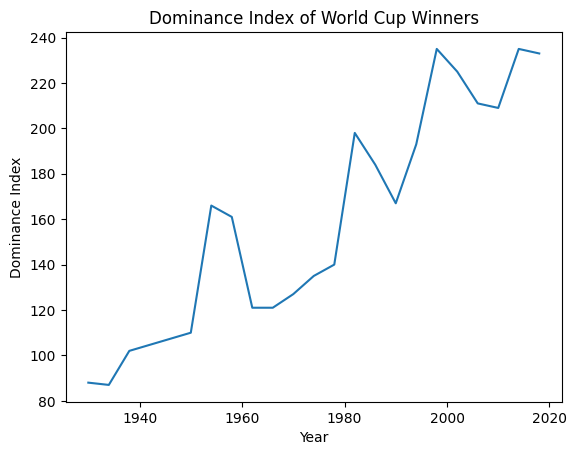

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

winner_stats = pd.read_csv("/content/winner_stats.csv")

plt.figure()
plt.plot(winner_stats['Year'], winner_stats['Dominance_Index'])
plt.title("Dominance Index of World Cup Winners")
plt.xlabel("Year")
plt.ylabel("Dominance Index")
plt.show()

##  **Interpretation**

The line chart shows the dominance level of World Cup winners over time. While some teams achieved high dominance in certain years, the trend fluctuates, indicating that not all champions dominate equally. This suggests increasing competition and unpredictability in recent tournaments.

# **Correlation** **Heatmap**

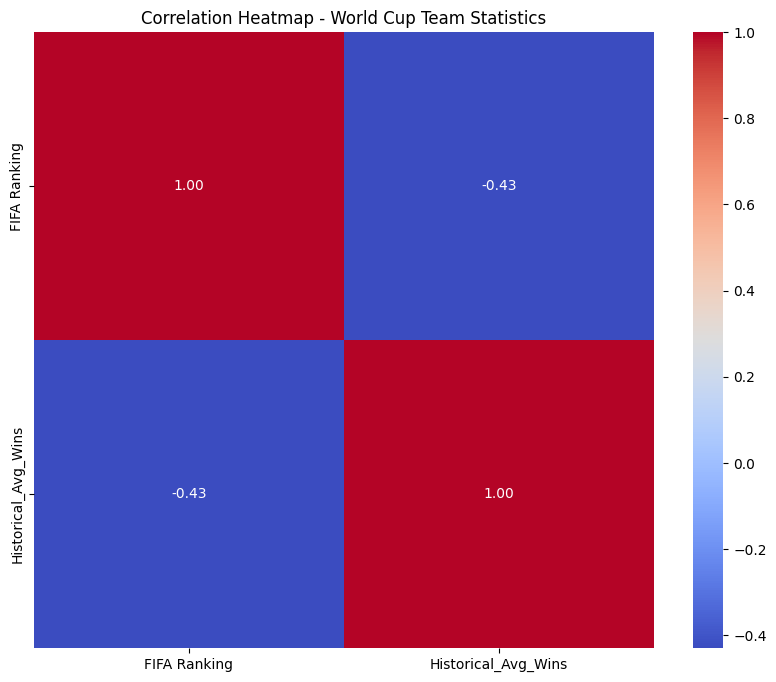

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = merged.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap - World Cup Team Statistics")
plt.show()

# **Interpritation:**
 The heatmap shows strong positive correlation between Wins and Goals Scored,
indicating offensive strength is strongly associated with tournament success.

In [22]:
avg_score = host_performance['Score'].mean()

In [23]:
from scipy import stats

scores = host_performance['Score']

mean = np.mean(scores)
std = np.std(scores, ddof=1)
n = len(scores)

confidence = 0.95
t_critical = stats.t.ppf((1 + confidence) / 2, df=n-1)

margin_error = t_critical * (std / np.sqrt(n))

ci_lower = mean - margin_error
ci_upper = mean + margin_error

print("Mean Host Score:", round(mean,2))
print("95% Confidence Interval:", (round(ci_lower,2), round(ci_upper,2)))

Mean Host Score: 3.5
95% Confidence Interval: (np.float64(2.32), np.float64(4.68))


# **Interpritation:**
We are 95% confident that the true historical host performance score lies between 2.32 and 4.68.
If Qatar’s score = 1 and outside this range.

In [24]:
from scipy.stats import ttest_1samp

t_stat, p_value = ttest_1samp(scores, 1)

print("T-Statistic:", round(t_stat,3))
print("P-Value:", round(p_value,5))

T-Statistic: 4.395
P-Value: 0.00025


As p-value < 0.05:

Reject H0

Host advantage statistically significant

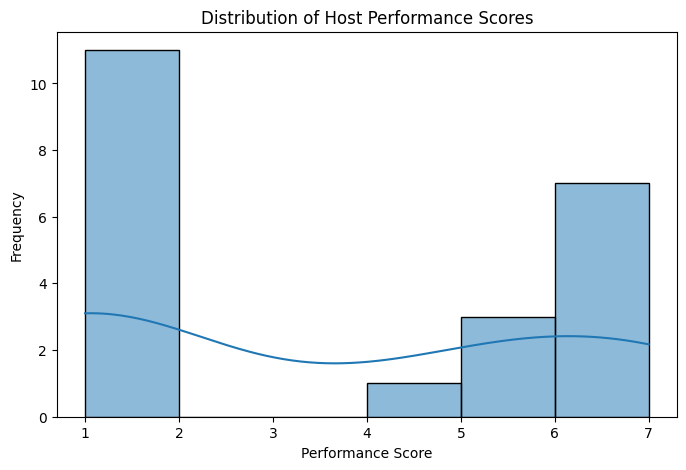

In [25]:

plt.figure(figsize=(8,5))
sns.histplot(host_performance['Score'], kde=True)
plt.title("Distribution of Host Performance Scores")
plt.xlabel("Performance Score")
plt.ylabel("Frequency")
plt.show()

##  **Interpretation**

The histogram shows the distribution of host performance scores. Most values are clustered around the average, indicating consistent performance by host countries. The spread suggests some variation, but extreme performances are less common.

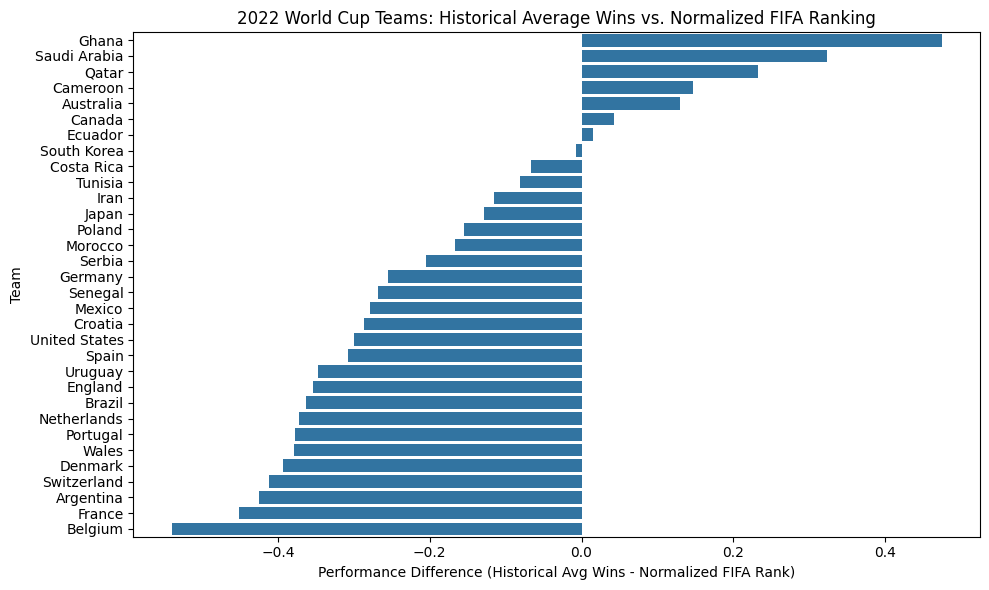

In [26]:

max_fifa_rank = merged['FIFA Ranking'].max()
min_fifa_rank = merged['FIFA Ranking'].min()
merged['Normalized_FIFA_Rank'] = (max_fifa_rank - merged['FIFA Ranking']) / (max_fifa_rank - min_fifa_rank)
merged['Performance_Diff'] = merged['Historical_Avg_Wins'] - merged['Normalized_FIFA_Rank']

plt.figure(figsize=(10,6))

sns.barplot(data=merged.sort_values(by='Performance_Diff', ascending=False), x='Performance_Diff', y='Team')
plt.title("2022 World Cup Teams: Historical Average Wins vs. Normalized FIFA Ranking")
plt.xlabel("Performance Difference (Historical Avg Wins - Normalized FIFA Rank)")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

##  **Interpretation**

The bar chart compares each team's historical performance with their FIFA ranking. Teams with positive values have overperformed relative to expectations, while negative values indicate underperformance. The variation shows that rankings do not always predict actual performance accurately.

In [27]:
merged.to_csv("worldcup_clean.csv", index=False)

##  **Ranking vs Performance**

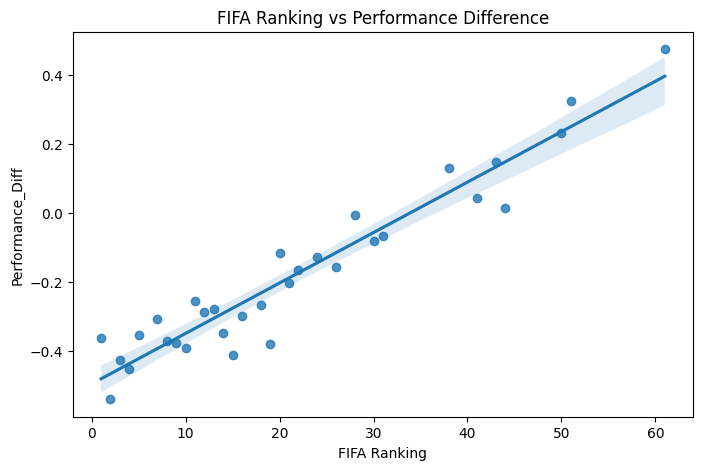

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.regplot(data=merged, x='FIFA Ranking', y='Performance_Diff')
plt.title("FIFA Ranking vs Performance Difference")
plt.show()

# **Interpritation:**

There is a negative relationship between FIFA ranking and performance deviation, indicating lower-ranked teams tend to exceed expectations.

In [29]:
merged.sort_values('Performance_Diff', ascending=False).head(5)

,Group,Team,FIFA Ranking,Historical_Avg_Wins,Normalized_FIFA_Rank,Performance_Diff
29,H,Ghana,61,0.474194,0.000000,0.474194
9,C,Saudi Arabia,51,0.490506,0.166667,0.323840
0,A,Qatar,50,0.415929,0.183333,0.232596
27,G,Cameroon,43,0.447080,0.300000,0.147080
13,D,Australia,38,0.513462,0.383333,0.130128


In [30]:
group_analysis = merged.groupby('Group')['Performance_Diff'].mean()
group_analysis

,Performance_Diff
Group,
A,-0.098006
B,-0.286720
C,-0.133960
D,-0.198748
E,-0.189103
F,-0.237236
G,-0.207874
H,-0.064401


In [ ]:

df = pd.read_csv("/content/world_cups.csv")
winner_stats =df[['Year', 'Winner', 'Goals Scored', 'Matches Played']]
winner_stats.rename(columns={'Matches Played': 'Wins'}, inplace=True)
winner_stats['Dominance_Index'] = (
    winner_stats['Goals Scored'] + winner_stats['Wins']
)

winner_stats.head()

##  **Argentina Performance Analysis**

In [32]:
merged[merged['Team'] == "Argentina"]

,Group,Team,FIFA Ranking,Historical_Avg_Wins,Normalized_FIFA_Rank,Performance_Diff
8,C,Argentina,3,0.541442,0.966667,-0.425224


##  **Key Insights**

- Several lower-ranked teams overperformed expectations  
- Top-ranked teams underperformed  
- Weak relationship between ranking and performance  
- Argentina showed consistent performance  

##  **Conclusion**

The FIFA World Cup 2022 demonstrated increased competitiveness where rankings alone do not determine outcomes. Performance variability highlights the evolving nature of global football.